# 광파오븐 지식인 데이터 분석
## LDA 토픽 모델링 → Actor / Action 도출
> **파일 준비**: `광파오븐_지식인.csv` 를 이 노트북과 같은 폴더(또는 Colab이면 `/content/`)에 넣어주세요.

## STEP 0. 패키지 설치

In [1]:
!pip install konlpy gensim pyLDAvis --quiet
# Java가 없으면 KoNLPy 오류 발생 → Colab은 아래 한 줄 추가 실행
# !apt-get install -y default-jdk > /dev/null 2>&1

## STEP 1. 라이브러리 임포트

In [2]:
import re
import warnings
import pandas as pd
from collections import Counter
from konlpy.tag import Okt
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='NanumGothic')   # Colab 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

okt = Okt()
print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## STEP 2. 전처리 설정
- **COMPOUND_MAP**: Okt에 넣기 전 복합어 통일 (에어프라이기 → 에어프라이어 등)
- **POST_MERGE**: 명사 추출 후 쪼개진 토큰 재합치기 (베이 + 킹 → 베이킹)
- **STOPWORDS**: LDA에 불필요한 단어 제거

In [3]:
COMPOUND_MAP = {
    '에어프라이어': '에어프라이어', '에어프라이기': '에어프라이어', '에어프라이': '에어프라이어',
    '광파오븐': '광파오븐', '광파렌지': '광파오븐', '광파 오븐': '광파오븐',
    '오븐레인지': '오븐레인지', '오븐렌지': '오븐레인지', '오븐 레인지': '오븐레인지',
    '전자레인지': '전자레인지', '전자렌지': '전자레인지', '전자 레인지': '전자레인지',
    '홈베이킹': '홈베이킹', '홈 베이킹': '홈베이킹',
    '사용설명서': '사용설명서', '멀티클린': '멀티클린', '스팀청소': '스팀청소',
}

POST3 = {('홈', '베이', '킹'): '홈베이킹'}
POST2 = {
    ('에어', '프라이어'): '에어프라이어', ('에어', '프라이'): '에어프라이어',
    ('광파', '오븐'): '광파오븐', ('오븐', '레인지'): '오븐레인지',
    ('전자', '레인지'): '전자레인지', ('베이', '킹'): '베이킹',
    ('멀티', '클린'): '멀티클린', ('오버', '쿡'): '오버쿡', ('빌트', '인'): '빌트인',
}

STOPWORDS = set([
    '것','수','이','가','을','를','은','는','에','의','도','로','와','과',
    '때','좀','더','안','못','잘','다','거','게','걸','건','저','제','그',
    '뭐','왜','어디','분','점','번','개','원','말','곳','문의','질문',
    '답변','채택','부탁','감사','혹시','이미','오늘','내일','어제',
    '이번','다음','모두','전부','경우','정도','방법','이유','사용','기능','제품','모델',
])
print('✅ 전처리 설정 완료')

✅ 전처리 설정 완료


## STEP 3. 전처리 함수 정의

In [4]:
def post_merge(tokens):
    """인접 토큰 재합치기: 베이+킹 → 베이킹 등"""
    merged = []
    i = 0
    while i < len(tokens):
        if i+2 < len(tokens) and (tokens[i], tokens[i+1], tokens[i+2]) in POST3:
            merged.append(POST3[(tokens[i], tokens[i+1], tokens[i+2])]); i += 3; continue
        if i+1 < len(tokens) and (tokens[i], tokens[i+1]) in POST2:
            merged.append(POST2[(tokens[i], tokens[i+1])]); i += 2; continue
        merged.append(tokens[i]); i += 1
    return merged


def preprocess(text):
    """LDA 입력용 명사 토큰 리스트 반환"""
    text = str(text)
    # 1) 노이즈 제거 (유튜브 자동 삽입 텍스트)
    for n in ['광고 후 계속됩니다', '다음 동영상', 'subject author', '재생 (space', '0초', '취소', '재생']:
        text = text.replace(n, ' ')
    # 2) URL 제거
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3) 복합어 치환
    for src, tgt in COMPOUND_MAP.items():
        text = text.replace(src, tgt)
    # 4) 특수문자 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # 5) Okt 명사 추출
    nouns = okt.nouns(text)
    # 6) 불용어 제거 + 2글자 이상
    nouns = [n for n in nouns if n not in STOPWORDS and len(n) >= 2]
    # 7) 인접 토큰 재합치기
    return post_merge(nouns)


# 테스트
test = '에어프라이기 기능을 수동으로 온도 설정하는 법 알려주세요'
print('원문 :', test)
print('토큰 :', preprocess(test))

원문 : 에어프라이기 기능을 수동으로 온도 설정하는 법 알려주세요
토큰 : ['에어프라이어', '수동', '온도', '설정']


## STEP 4. 데이터 로드 & 전처리 실행
> Colab 사용 시 파일 경로를 `/content/광파오븐_지식인.csv` 로 변경하세요.

In [5]:
# ▼ 파일 경로 수정
FILE_PATH = '광파오븐_지식인.csv'

df = pd.read_csv(FILE_PATH)
df = df.drop_duplicates(subset=['제목', '본문']).copy()
df['본문_clean'] = df['본문'].str.replace(r'\n|\t', ' ', regex=True).str.strip()
df['전체텍스트'] = df['제목'].fillna('') + ' ' + df['본문_clean'].fillna('')

print('전처리 중... (1~2분 소요)')
df['tokens'] = df['전체텍스트'].apply(preprocess)
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
print(f'✅ 완료: {len(df)}개 문서')
df[['제목', 'tokens']].head(3)

전처리 중... (1~2분 소요)
✅ 완료: 605개 문서


,제목,tokens
0,인덕션 밑에 광파오븐...,"[인덕션, 광파오븐, 인덕션, 광파오븐, 기존, 빌트, 제거, 하니, 공간, 보기,..."
1,빌트인 광파오븐 청소,"[빌트, 광파오븐, 청소, 구입, 한지, 개월, 빌트, 오븐, 호빵, 홀라당, 오븐..."
2,광파오븐 문의,"[광파오븐, 전자레인지, 석쇠, 바닥, 하나요, 그릇, 음식, 법랑, 접시, 전자레..."


## STEP 5. Dictionary & Corpus 생성
- `no_below=3` : 3개 미만 문서에 등장하는 단어 제거
- `no_above=0.85` : 전체 85% 이상 문서에 등장하는 단어 제거 (너무 흔한 단어)

In [6]:
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=3, no_above=0.85)
corpus = [dictionary.doc2bow(doc) for doc in df['tokens']]

print(f'사전 크기 : {len(dictionary)}개 단어')
print(f'코퍼스 크기: {len(corpus)}개 문서')

사전 크기 : 722개 단어
코퍼스 크기: 605개 문서


## STEP 6. 최적 토픽 수 탐색 (Coherence Score)
Coherence Score가 **가장 높은 k** 가 최적 토픽 수입니다.

  topics=3  coherence=0.3707
  topics=4  coherence=0.3206
  topics=5  coherence=0.3516
  topics=6  coherence=0.4547
  topics=7  coherence=0.4473
  topics=8  coherence=0.4373

▶ 최적 토픽 수: 6개


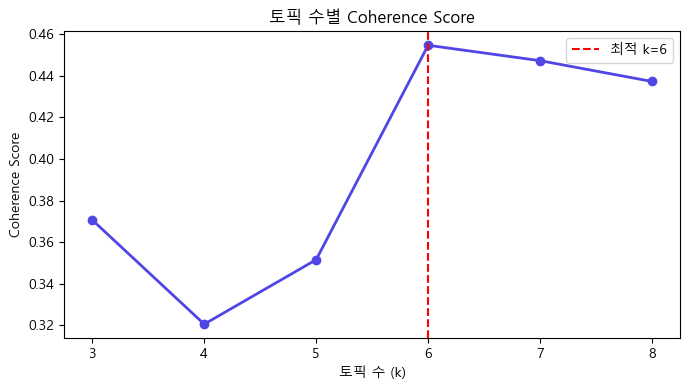

In [16]:
coherence_scores = []

for k in range(3, 9):
    model = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=k, passes=15, random_state=42, alpha='auto'
    )
    cm = CoherenceModel(
        model=model, texts=df['tokens'],
        dictionary=dictionary, coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append((k, round(score, 4)))
    print(f'  topics={k}  coherence={score:.4f}')

best_k = max(coherence_scores, key=lambda x: x[1])[0]
print(f'\n▶ 최적 토픽 수: {best_k}개')

# 시각화
ks, scores = zip(*coherence_scores)
plt.figure(figsize=(7, 4))
plt.plot(ks, scores, marker='o', color='#4f46e5', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'최적 k={best_k}')
plt.xlabel('토픽 수 (k)'); plt.ylabel('Coherence Score')
plt.title('토픽 수별 Coherence Score')
plt.legend(); plt.tight_layout(); plt.show()

## STEP 7. 최종 LDA 모델 학습

In [17]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    passes=20,       # 반복 횟수 (많을수록 정확, 느림)
    random_state=42,
    alpha='auto',    # 문서-토픽 분포 자동 최적화
    eta='auto'       # 토픽-단어 분포 자동 최적화
)

print('✅ 학습 완료!\n')
print('=== 토픽별 상위 키워드 ===')
for i in range(best_k):
    words = lda_model.show_topic(i, topn=10)
    kw_str = ' / '.join([f"{w}({p:.3f})" for w, p in words])
    print(f'  Topic {i}: {kw_str}')

✅ 학습 완료!

=== 토픽별 상위 키워드 ===
  Topic 0: 수납(0.038) / 추천(0.029) / 이사(0.029) / 냉장고(0.028) / 주방(0.024) / 광파오븐(0.020) / 침대(0.018) / 식탁(0.016) / 책상(0.016) / 견적(0.014)
  Topic 1: 오븐(0.114) / 광파오븐(0.064) / 전자레인지(0.046) / 빌트(0.027) / 추천(0.020) / 엘지(0.019) / 인덕션(0.017) / 설치(0.016) / 베이(0.016) / 시간(0.012)
  Topic 2: 오븐(0.036) / 쿠키(0.028) / 머랭(0.020) / 레시피(0.018) / 검사(0.017) / 계란(0.016) / 버터(0.012) / 그냥(0.012) / 다른(0.012) / 추천(0.011)
  Topic 3: 광파오븐(0.032) / 추천(0.028) / 아파트(0.012) / 실제(0.011) / 쿠쿠(0.010) / 선택(0.010) / 온도(0.010) / 설치(0.010) / 에어컨(0.010) / 전자레인지(0.010)
  Topic 4: 광파오븐(0.101) / 오븐(0.057) / 청소(0.042) / 전자레인지(0.026) / 에어프라이어(0.026) / 스팀(0.023) / 오브(0.022) / 차이(0.016) / 베이(0.015) / 구매(0.012)
  Topic 5: 설정(0.048) / 에어프라이어(0.047) / 광파오븐(0.034) / 해상도(0.031) / 음소거(0.031) / 소리(0.030) / 자동(0.028) / 기본(0.023) / 안함(0.021) / 속도(0.021)


## STEP 8. 문서별 토픽 할당

In [18]:
def get_main_topic(tokens):
    bow = dictionary.doc2bow(tokens)
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return sorted(topics, key=lambda x: -x[1])[0][0]

df['topic_id'] = df['tokens'].apply(get_main_topic)

print('토픽별 문서 수:')
print(df['topic_id'].value_counts().sort_index())
print()
print('=== 토픽별 대표 질문 (각 3개) ===')
for t in range(best_k):
    titles = df[df['topic_id'] == t]['제목'].head(3).tolist()
    print(f'  Topic {t}: {titles}')

토픽별 문서 수:
topic_id
0     69
1    184
2     56
3     79
4    157
5     60
Name: count, dtype: int64

=== 토픽별 대표 질문 (각 3개) ===
  Topic 0: ['광파오븐 아일랜드 홈바 추천해주세오', '김치 냉장고 수납장 비스포크 광파오븐 렌지대 추천', '광파오븐 렌지대 추천부탁드려요']
  Topic 1: ['인덕션 밑에 광파오븐...', '광파오븐 문의', '광파오븐 사용법']
  Topic 2: ['Lg 광파오븐 하부장 문의', 'MZ385EBT lg 광파오븐 오류', '광파오븐으로 쿠키']
  Topic 3: ['소형가전 유리로된 광파오븐  버리는법', '쿠쿠 멀티광파오븐 온도 설정', 'LG 광파오븐 작동시 소음']
  Topic 4: ['빌트인 광파오븐 청소', '광파오븐 조리 화재', 'LG 광파오븐 사운드 무음']
  Topic 5: ['광파오븐 질문입니다.', 'Lg광파오븐 에어프라이어  소음', '엘지 광파오븐 에어프라이기 기능']


## STEP 9. 토픽 라벨링
> ⚠️ **STEP 7 결과를 보고 아래 딕셔너리를 직접 수정하세요.**  
> 토픽별 키워드를 보고 의미에 맞는 이름을 붙입니다.

In [19]:
# ▼▼▼ 실행 결과 보고 직접 수정 ▼▼▼
TOPIC_LABEL = {
    0: '기기 오작동/소음/설정 문제',
    1: '주방 공간 배치 및 인테리어 고민',
    2: '신축/이사 입주 시 가전 선택',
    3: '이사/생활 주변 맥락 (광파오븐 포함)',
    4: '광파오븐 핵심 사용/구매/레시피',
}
# ▲▲▲ 여기까지 수정 ▲▲▲

df['topic_label'] = df['topic_id'].map(TOPIC_LABEL).fillna('미분류')
print('적용된 토픽 라벨:')
for k, v in TOPIC_LABEL.items():
    count = (df['topic_id'] == k).sum()
    print(f'  Topic {k} ({count:3d}건): {v}')

적용된 토픽 라벨:
  Topic 0 ( 69건): 기기 오작동/소음/설정 문제
  Topic 1 (184건): 주방 공간 배치 및 인테리어 고민
  Topic 2 ( 56건): 신축/이사 입주 시 가전 선택
  Topic 3 ( 79건): 이사/생활 주변 맥락 (광파오븐 포함)
  Topic 4 (157건): 광파오븐 핵심 사용/구매/레시피


## STEP 10. Actor / Action 도출
> ⚠️ **STEP 9 라벨을 기반으로 아래를 직접 수정하세요.**  
> - `actor` : 이 토픽의 질문을 올린 사람은 누구인가?
> - `action`: 그 사람이 하려는 행동은 무엇인가?
> - `need`  : 실제로 필요한 콘텐츠/서비스는 무엇인가?

In [20]:
# ▼▼▼ 실행 결과 보고 직접 수정 ▼▼▼
ACTOR_ACTION = {
    0: {
        'actor' : '제품 결함 경험자',
        'action': '소음/오류 원인 파악 → AS 여부 판단 → 설정 변경 시도',
        'need'  : '증상별 자가진단 가이드, AS 연결 콘텐츠',
    },
    1: {
        'actor' : '주방 인테리어/이사 준비 중 사용자',
        'action': '광파오븐 배치 위치 탐색 → 렌지대·수납가구 추천 요청',
        'need'  : '공간 배치 가이드, 렌지대 호환성 정보',
    },
    2: {
        'actor' : '새 아파트 입주자 / 처음 독립하는 사용자',
        'action': '빌트인 가전 옵션 결정 → 처음 사용 주의사항 파악',
        'need'  : '신혼/입주 가전 선택 가이드, 첫 사용 온보딩 콘텐츠',
    },
    3: {
        'actor' : '이사 준비 중 1인가구',
        'action': '이사 짐 목록에 광파오븐 포함 → 비용·처리 방법 탐색',
        'need'  : '이사 시 가전 처리 방법, 중고 처분/폐기 안내',
    },
    4: {
        'actor' : '광파오븐 구매자 / 일상 사용자',
        'action': '기능 문의 → 사용법 학습 → 청소 → 베이킹 레시피 탐색',
        'need'  : '모델 맞춤 레시피, 에어프라이 수동 설정 가이드, 청소 루틴 알림',
    },
}
# ▲▲▲ 여기까지 수정 ▲▲▲

print('=' * 80)
print(f'{"Topic":<8} {"라벨":<26} {"Actor":<24} 핵심 Needs')
print('-' * 80)
for tid, info in ACTOR_ACTION.items():
    label = TOPIC_LABEL.get(tid, '')
    count = (df['topic_id'] == tid).sum()
    print(f'T{tid}({count:3d}건) {label:<25} {info["actor"]:<23} {info["need"]}')

print()
print('상세 Actor / Action:')
for tid, info in ACTOR_ACTION.items():
    label = TOPIC_LABEL.get(tid, '')
    count = (df['topic_id'] == tid).sum()
    print(f'\n[Topic {tid}] {label} ({count}건)')
    print(f'  Actor  : {info["actor"]}')
    print(f'  Action : {info["action"]}')
    print(f'  Needs  : {info["need"]}')
    samples = df[df['topic_id'] == tid]['제목'].head(3).tolist()
    print(f'  대표질문: {samples}')

Topic    라벨                         Actor                    핵심 Needs
--------------------------------------------------------------------------------
T0( 69건) 기기 오작동/소음/설정 문제           제품 결함 경험자               증상별 자가진단 가이드, AS 연결 콘텐츠
T1(184건) 주방 공간 배치 및 인테리어 고민        주방 인테리어/이사 준비 중 사용자     공간 배치 가이드, 렌지대 호환성 정보
T2( 56건) 신축/이사 입주 시 가전 선택          새 아파트 입주자 / 처음 독립하는 사용자 신혼/입주 가전 선택 가이드, 첫 사용 온보딩 콘텐츠
T3( 79건) 이사/생활 주변 맥락 (광파오븐 포함)     이사 준비 중 1인가구            이사 시 가전 처리 방법, 중고 처분/폐기 안내
T4(157건) 광파오븐 핵심 사용/구매/레시피         광파오븐 구매자 / 일상 사용자       모델 맞춤 레시피, 에어프라이 수동 설정 가이드, 청소 루틴 알림

상세 Actor / Action:

[Topic 0] 기기 오작동/소음/설정 문제 (69건)
  Actor  : 제품 결함 경험자
  Action : 소음/오류 원인 파악 → AS 여부 판단 → 설정 변경 시도
  Needs  : 증상별 자가진단 가이드, AS 연결 콘텐츠
  대표질문: ['광파오븐 아일랜드 홈바 추천해주세오', '김치 냉장고 수납장 비스포크 광파오븐 렌지대 추천', '광파오븐 렌지대 추천부탁드려요']

[Topic 1] 주방 공간 배치 및 인테리어 고민 (184건)
  Actor  : 주방 인테리어/이사 준비 중 사용자
  Action : 광파오븐 배치 위치 탐색 → 렌지대·수납가구 추천 요청
  Needs  : 공간 배치 가이드, 렌지대 호환성 정보
  대표질문: ['인덕션 밑에 광파오븐...', '광파오븐 문

## STEP 11. 시각화

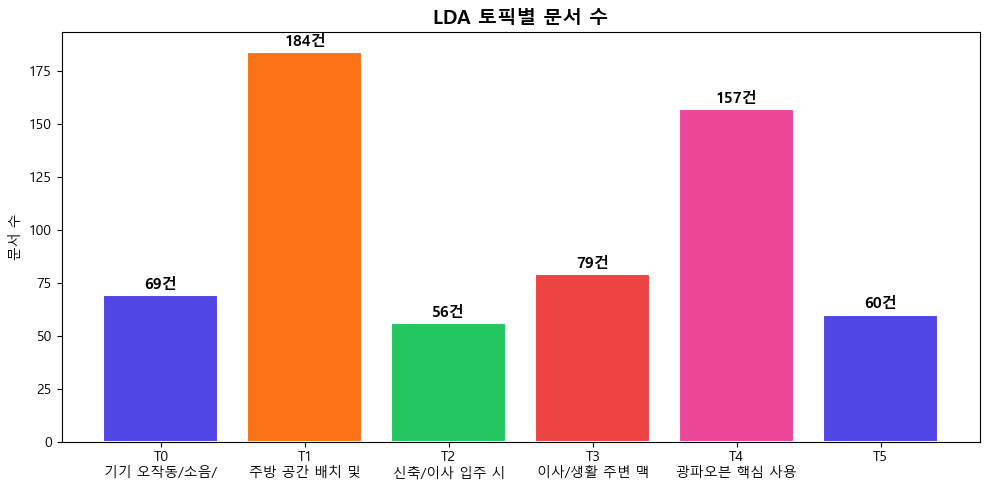

In [21]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='Malgun Gothic')   # Windows 기본 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

# 토픽별 문서 수 바 차트
topic_counts = df['topic_id'].value_counts().sort_index()
labels = [f"T{i}\n{TOPIC_LABEL.get(i,'')[:10]}" for i in topic_counts.index]
colors = ['#4f46e5','#f97316','#22c55e','#ef4444','#ec4899']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, topic_counts.values,
               color=colors[:len(topic_counts)], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}건', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('LDA 토픽별 문서 수', fontsize=14, fontweight='bold')
plt.ylabel('문서 수'); plt.tight_layout(); plt.show()

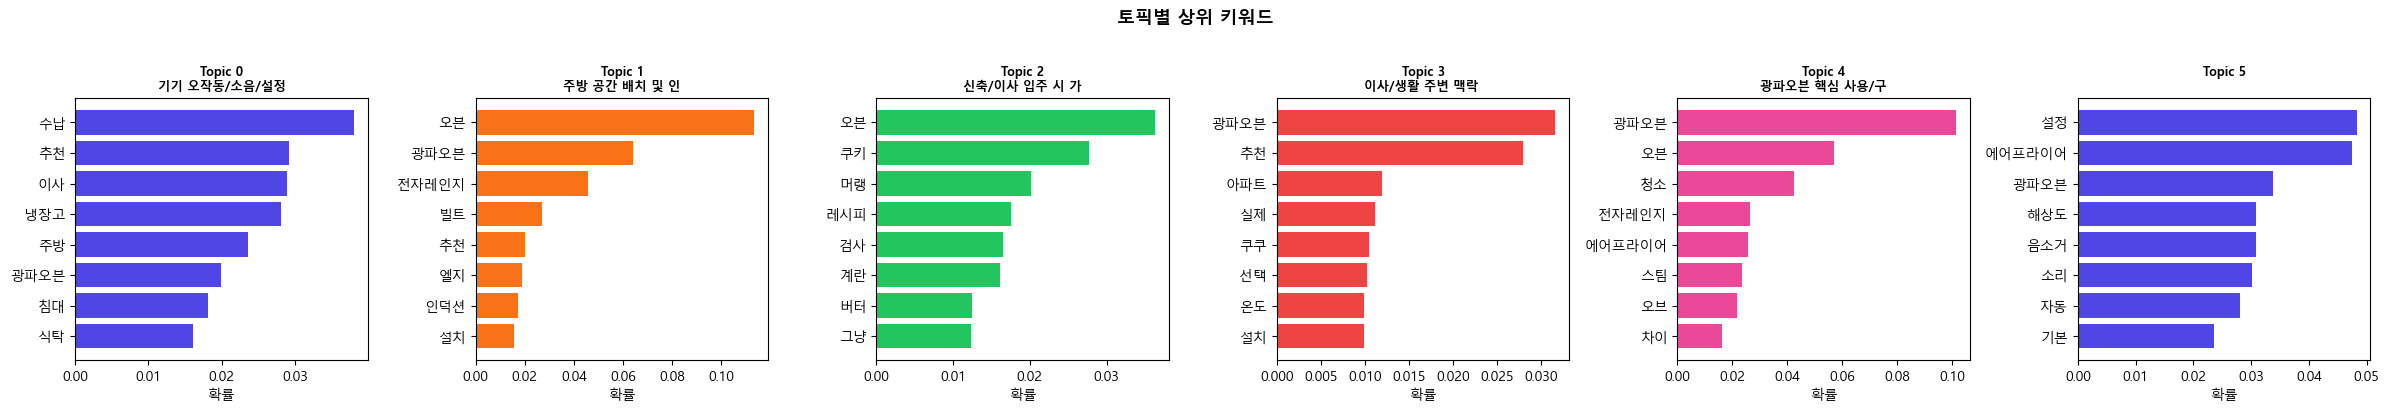

In [22]:
# 토픽별 상위 키워드 수평 바 차트
fig, axes = plt.subplots(1, best_k, figsize=(4 * best_k, 4))
for i, ax in enumerate(axes):
    words_probs = lda_model.show_topic(i, topn=8)
    words, probs = zip(*words_probs)
    ax.barh(words[::-1], probs[::-1], color=colors[i % len(colors)])
    ax.set_title(f'Topic {i}\n{TOPIC_LABEL.get(i,"")[:12]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('확률')
plt.suptitle('토픽별 상위 키워드', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## STEP 12. 결과 저장

In [23]:
# 12-1. 문서별 토픽 분류 결과
df[['제목', '본문_clean', 'topic_id', 'topic_label']].to_csv(
    'LDA_토픽분류_결과.csv', index=False, encoding='utf-8-sig'
)
print('✅ LDA_토픽분류_결과.csv 저장')

# 12-2. Actor/Action 요약표
rows = []
for tid, info in ACTOR_ACTION.items():
    count = (df['topic_id'] == tid).sum()
    rows.append({
        'topic_id'   : tid,
        'topic_label': TOPIC_LABEL.get(tid, ''),
        'count'      : count,
        'actor'      : info['actor'],
        'action'     : info['action'],
        'need'       : info['need'],
    })
actor_df = pd.DataFrame(rows)
actor_df.to_csv('Actor_Action_요약.csv', index=False, encoding='utf-8-sig')
print('✅ Actor_Action_요약.csv 저장')

# 12-3. 토픽별 키워드 확률
kw_rows = []
for i in range(best_k):
    for rank, (word, prob) in enumerate(lda_model.show_topic(i, topn=15), 1):
        kw_rows.append({'topic_id': i, 'topic_label': TOPIC_LABEL.get(i,''),
                        'rank': rank, 'keyword': word, 'probability': round(prob, 4)})
pd.DataFrame(kw_rows).to_csv('LDA_토픽_키워드.csv', index=False, encoding='utf-8-sig')
print('✅ LDA_토픽_키워드.csv 저장')

print('\n🎉 전체 분석 완료!')
actor_df

✅ LDA_토픽분류_결과.csv 저장
✅ Actor_Action_요약.csv 저장
✅ LDA_토픽_키워드.csv 저장

🎉 전체 분석 완료!


,topic_id,topic_label,count,actor,action,need
0,0,기기 오작동/소음/설정 문제,69,제품 결함 경험자,소음/오류 원인 파악 → AS 여부 판단 → 설정 변경 시도,"증상별 자가진단 가이드, AS 연결 콘텐츠"
1,1,주방 공간 배치 및 인테리어 고민,184,주방 인테리어/이사 준비 중 사용자,광파오븐 배치 위치 탐색 → 렌지대·수납가구 추천 요청,"공간 배치 가이드, 렌지대 호환성 정보"
2,2,신축/이사 입주 시 가전 선택,56,새 아파트 입주자 / 처음 독립하는 사용자,빌트인 가전 옵션 결정 → 처음 사용 주의사항 파악,"신혼/입주 가전 선택 가이드, 첫 사용 온보딩 콘텐츠"
3,3,이사/생활 주변 맥락 (광파오븐 포함),79,이사 준비 중 1인가구,이사 짐 목록에 광파오븐 포함 → 비용·처리 방법 탐색,"이사 시 가전 처리 방법, 중고 처분/폐기 안내"
4,4,광파오븐 핵심 사용/구매/레시피,157,광파오븐 구매자 / 일상 사용자,기능 문의 → 사용법 학습 → 청소 → 베이킹 레시피 탐색,"모델 맞춤 레시피, 에어프라이 수동 설정 가이드, 청소 루틴 알림"
